In [ ]:
from PIL import Image 
from matplotlib import pyplot as plt 
import sys 
sys.path.append('..')
from train import TrainModel 
import torch 
from custom_dataset.dataset import predict_by_name_processing

In [1]:
device = torch.device("cuda:0")
model = TrainModel.load_from_checkpoint("/home/kathy/projects/project_guo/test/best_model/version_7/checkpoints/epoch=499-step=30500.ckpt", map_location=device)


NameError: name 'torch' is not defined

In [5]:
img_model, masks_model = predict_by_name_processing("19_6.png")

In [1]:
img_model, masks_model = img_model.to(model.device), masks_model.to(model.device)

NameError: name 'img_model' is not defined

In [7]:
output = model(img_model)

/home/kathy/anaconda3/envs/hkx/lib/python3.8/site-packages/torch/nn/functional.py:3722: UserWarning: nn.functional.upsample is deprecated. Use nn.functional.interpolate instead.
  warnings.warn("nn.functional.upsample is deprecated. Use nn.functional.interpolate instead.")


In [8]:
output.shape 

torch.Size([4, 5, 128, 128])

In [9]:
pred = output.argmax(dim = 1)

In [10]:
pred.shape 


torch.Size([4, 128, 128])

In [11]:
pred_mask = torch.concat(
    (
        torch.concat((pred[0, ...], pred[3, ...])), 
        torch.concat((pred[1, ...], pred[2, ...])), 
    ) , dim = 1
) 

In [28]:
true_mask = torch.concat(
    (
        torch.concat((pred[0, ...], pred[3, ...])), 
        torch.concat((pred[1, ...], pred[2, ...])), 
    ) , dim = 1
) 

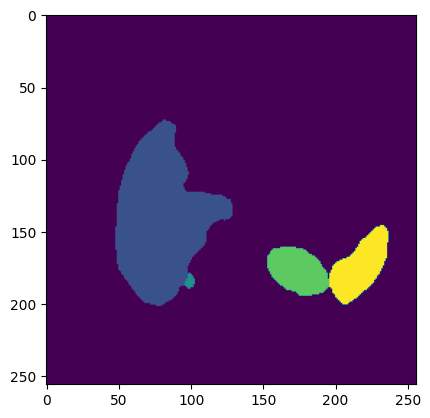

In [12]:
plt.imshow(pred_mask.detach().cpu().numpy())

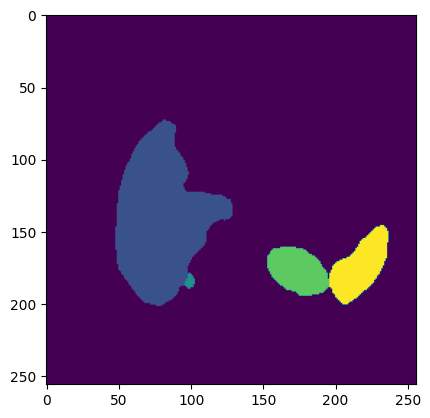

In [29]:
plt.imshow(true_mask.detach().cpu().numpy())

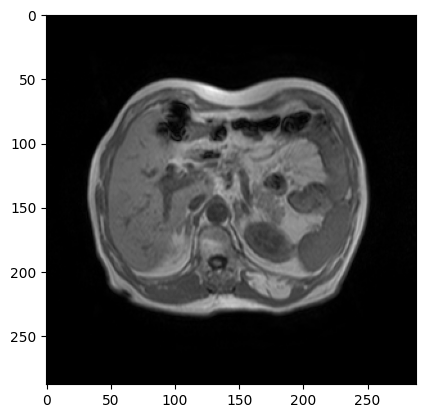

In [14]:
img = plt.imread('/home/kathy/projects/project_guo/train/image/20_17.png')
plt.imshow(img, cmap = "gray")

In [16]:
import numpy as np 

In [15]:
import cv2 

In [17]:
img.shape

(288, 288)

In [33]:
img.shape 

(288, 288)

In [34]:
img = img[:256, :256]
true_mask = true_mask.detach().cpu().numpy()


In [50]:
true_mask.shape , img.shape 

((256, 256), (256, 256))

In [66]:
overlay = np.ones(shape = (256, 256, 3))

# 定义颜色
colors = [
    (0, 0, 0),    # 背景 - 黑色
    (0, 255, 0),  # 器官1 - 绿色
    (255, 0, 0),  # 器官2 - 蓝色
    (0, 0, 255),   # 器官3 - 红色
    (0, 122, 122)   # 器官3 - 红色
]
# 将每个器官绘制到overlay上
for i in range(1, 5):  # 假设类别从1到4
    overlay[true_mask == i] = colors[i]

# 将标签图像overlay叠加到医学图像上
result = cv2.addWeighted(img, 0.5, overlay.astype("float32"), 0.5, 0)


error: OpenCV(4.6.0) /io/opencv/modules/core/src/arithm.cpp:647: error: (-209:Sizes of input arguments do not match) The operation is neither 'array op array' (where arrays have the same size and the same number of channels), nor 'array op scalar', nor 'scalar op array' in function 'arithm_op'


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


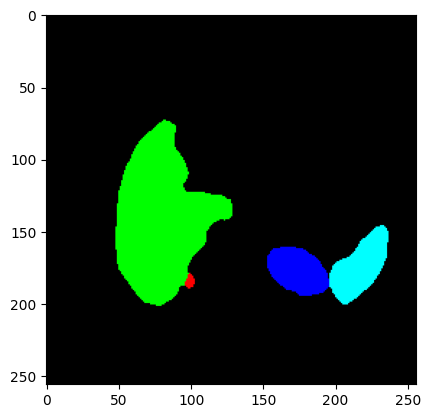

In [67]:
plt.imshow(overlay)

In [74]:
img.shape, overlay.shape 

((256, 256), (256, 256, 3))

In [77]:
background = cv2.cvtColor(img, cv2.COLOR_GRAY2BGR)

In [78]:
result = cv2.addWeighted(background, 0.5, overlay.astype("float32"), 0.5, 0)


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


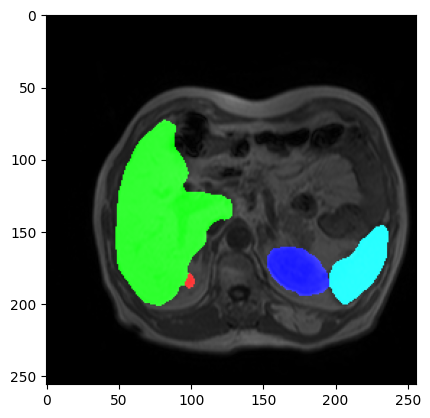

In [79]:
plt.imshow(result)

In [71]:
result = cv2.addWeighted(img, 0.5, true_mask.astype("float32"), 0.5, 0)


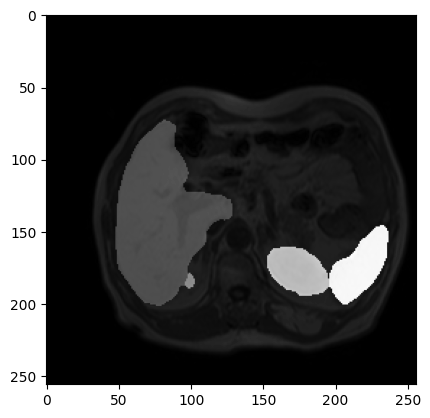

In [47]:
plt.imshow(result, cmap = "gray")

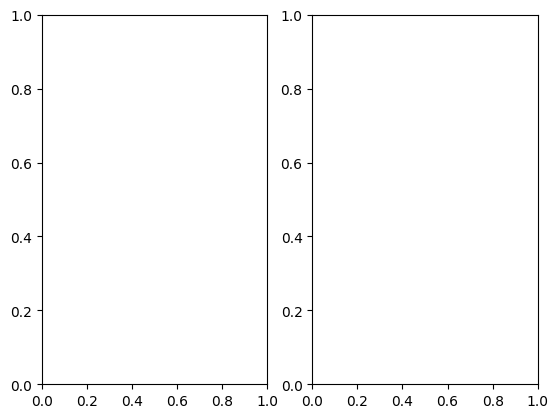

In [81]:
fig , axes = plt.subplots(1, 2)
plt.savefig('./demo.png')

In [43]:
img.dtype

dtype('float32')

In [42]:
true_mask.dtype 

dtype('int64')

In [19]:
overlay.shape 

(288, 288)

In [32]:
true_mask.shape 

(256, 256)

In [37]:
overlay[true_mask == 4]

array([0., 0., 0., ..., 0., 0., 0.], dtype=float32)

In [25]:
np.unique(true_mask)

array([0.        , 0.24705882, 0.49411765, 0.7411765 , 0.9882353 ],
      dtype=float32)

In [27]:
masks_model.unique() 

tensor([0, 1, 2, 3, 4], device='cuda:0')